# 01.4 — Controlled experiments and honest comparisons

**CPU · Seed 42 · Synthetic image · No model**

## Learning Objectives

Translate a loop into vectorized NumPy, compare with OpenCV on the same operation, visualize parameter sweeps, measure local runtime and distinguish array storage from peak memory. Assemble a reproducible Pixel Lab report.

## Prerequisites

The previous three notebooks: RGB arrays, dtype, clipping, functions, classes, file handling and plotting. This notebook creates a fresh input and has no cross-notebook variables.

## 1. Introduction

A plot may look plausible even when two implementations do different things. We first specify the operation, check equality and only then measure runtime. We also record what the measurement excludes.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import cv2
import matplotlib.pyplot as plt
import numpy as np

from cvzero.benchmark import benchmark_brightness
from cvzero.images import adjust_brightness, brightness_loop, channel_histograms
from cvzero.lab import LabConfig, run_lab
from cvzero.synthetic import make_scene

seed = 42
image = make_scene(96, 128, seed=seed)
baseline = image.copy()
print("Workload:", image.shape, image.dtype, "seed", seed)

Workload: (96, 128, 3) uint8 seed 42


## 2. Intuition

Compare three workers asked to perform exactly the same recipe. A Python loop describes every repeated step. NumPy describes the operation on an entire array. OpenCV calls an optimized image operation. A fair comparison gives each worker the same input and checks the same output.

A faster arithmetic worker does not automatically make a whole video system faster: decoding, queues, display, storage and scheduling may dominate elsewhere.

## 3. Mathematical Foundation

The operation is $J=\operatorname{round}(\operatorname{clip}(I+30,0,255))$. $I$ is the RGB array, $J$ its edited copy, and 30 is the additive offset. For channels `(240,20,0)`, the result is `(255,50,30)`.

We report maximum absolute pixel error $e_{\max}=\max_i|a_i-b_i|$. Here $a_i$ and $b_i$ are corresponding output channel values from two implementations. Convert to a signed type before subtracting so a negative difference does not wrap. Equality means $e_{\max}=0$ for this integer-offset comparison; it is not a model accuracy metric.

For timings, a median is the middle of the sorted measured values. For hypothetical samples 2, 3 and 20 ms, it is 3 ms. These numbers are an arithmetic example, not results from this notebook.

## 4. Visual Explanation

A brightness sweep changes one parameter while keeping the seed, input and display convention fixed. This makes causality easier to discuss. Large positive offsets saturate values; once clipped, their original differences cannot be recovered from the output.

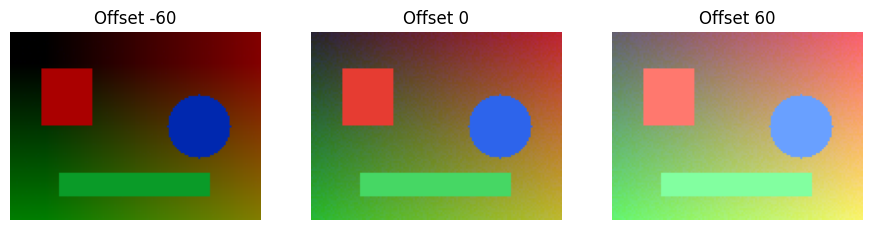

In [2]:
offsets = [-60, 0, 60]
outputs = [adjust_brightness(image, delta) for delta in offsets]
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, delta, output in zip(axes, offsets, outputs, strict=True):
    ax.imshow(output)
    ax.set_title(f"Offset {delta}")
    ax.set_axis_off()
plt.show()

## 5. Basic Implementation

This whole-array expression says exactly what the scalar recipe did: convert before addition, clip, round and cast. It returns a new array. The input remains available for a trustworthy comparison.

In [3]:
def brightness_numpy(rgb, delta):
    floating = rgb.astype(np.float64)
    shifted = floating + delta
    clipped = np.clip(shifted, 0, 255)
    return np.rint(clipped).astype(np.uint8)


numpy_result = brightness_numpy(image, 30)
np.testing.assert_array_equal(numpy_result, adjust_brightness(image, 30))
np.testing.assert_array_equal(image, baseline)

## 6. OpenCV Implementation

`addWeighted` computes a weighted sum of two arrays plus a scalar offset. With weights 1 and 0, it becomes the first image plus the offset. For `uint8` output the image arithmetic saturates at the representable limits. A positive integer offset makes an exact comparison appropriate here.

In [4]:
opencv_result = cv2.addWeighted(image, 1.0, image, 0.0, 30.0)
error = np.abs(opencv_result.astype(np.int16) - numpy_result.astype(np.int16))
print("OpenCV versus NumPy maximum pixel error:", int(error.max()))
assert error.max() == 0

OpenCV versus NumPy maximum pixel error: 0


## 7. From-Scratch Implementation

Now run the explicit reference loop already explained in the chapter. Read `src/cvzero/images.py` to inspect its three nested loops. This compact local version makes the repeated arithmetic visible before comparing performance.

In [5]:
def brightness_scalar(rgb, delta):
    result = np.empty_like(rgb)
    for row in range(rgb.shape[0]):
        for column in range(rgb.shape[1]):
            for channel in range(3):
                value = float(rgb[row, column, channel]) + delta
                result[row, column, channel] = round(min(255.0, max(0.0, value)))
    return result


loop_result = brightness_scalar(image, 30)
np.testing.assert_array_equal(loop_result, numpy_result)
np.testing.assert_array_equal(brightness_loop(image, 30), numpy_result)
print("All three implementations agree for this workload.")

All three implementations agree for this workload.


## 8. Experiment

Run the benchmark only after correctness checks. The helper uses the same 96×128 RGB image, offset 30, one warm-up per method, five measured repeats and one OpenCV thread. It records all samples and restores the previous thread setting. Allocation is included; disk I/O and plotting are excluded.

Change `repeats` if you want more samples. Changing image size requires a separate controlled experiment rather than comparing numbers from different workloads.

In [6]:
benchmark = benchmark_brightness(repeats=5, seed=seed)
for row in benchmark["results"]:
    print(
        f"{row['implementation']:12s}: median {row['median_ms']:.4f} ms; "
        f"max pixel error {row['max_absolute_pixel_error']}"
    )
print("Python:", benchmark["environment"]["python"])
print("Machine:", benchmark["environment"]["machine"])
print("Input element bytes:", benchmark["results"][0]["input_array_bytes"])
assert all(row["max_absolute_pixel_error"] == 0 for row in benchmark["results"])

python_loop : median 13.7870 ms; max pixel error 0
numpy       : median 0.0422 ms; max pixel error 0
opencv      : median 0.0064 ms; max pixel error 0
Python: 3.12.14
Machine: x86_64
Input element bytes: 36864


These are measurements from the kernel running this notebook. They are not universal speed claims. Element byte counts exclude temporary arrays, interpreter objects and process overhead; peak memory is explicitly not measured. PyTorch comparisons arrive after tensors and device synchronization have been taught.

## 9. Visualization

The timing axis is logarithmic because the methods may differ substantially. The histogram counts pixels at every intensity; its count sum must equal the number of pixels in each channel. A histogram does not retain the image's spatial layout.

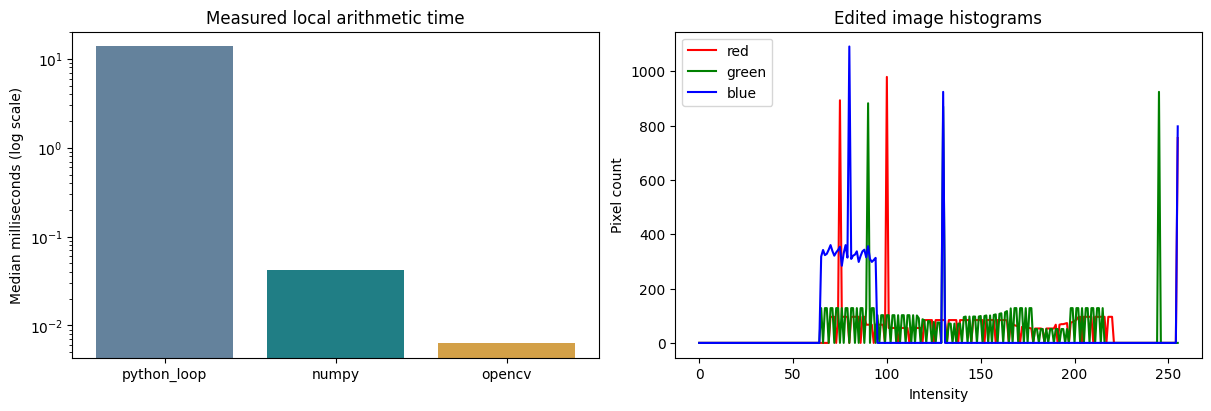

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
rows = benchmark["results"]
axes[0].bar(
    [row["implementation"] for row in rows],
    [row["median_ms"] for row in rows],
    color=["#64829c", "#207e85", "#d3a047"],
)
axes[0].set_yscale("log")
axes[0].set(ylabel="Median milliseconds (log scale)", title="Measured local arithmetic time")
counts = channel_histograms(numpy_result)
for channel, color in enumerate(["red", "green", "blue"]):
    axes[1].plot(np.arange(256), counts[channel], color=color, label=color)
axes[1].set(xlabel="Intensity", ylabel="Pixel count", title="Edited image histograms")
axes[1].legend()
np.testing.assert_array_equal(counts.sum(axis=1), [96 * 128] * 3)
plt.show()

## 10. Real-World Application

Combine the data, settings and plots in an inspectable report. Below we use a temporary folder so the notebook can be rerun safely. To retain your own report, use the CLI command `python -m cvzero demo --output artifacts/my-new-run` from the repository root.

Created: ['contact-sheet.png', 'edited.png', 'grayscale.png', 'histograms.png', 'original.png', 'report.html', 'summary.json']
Edited size: 128 x 96


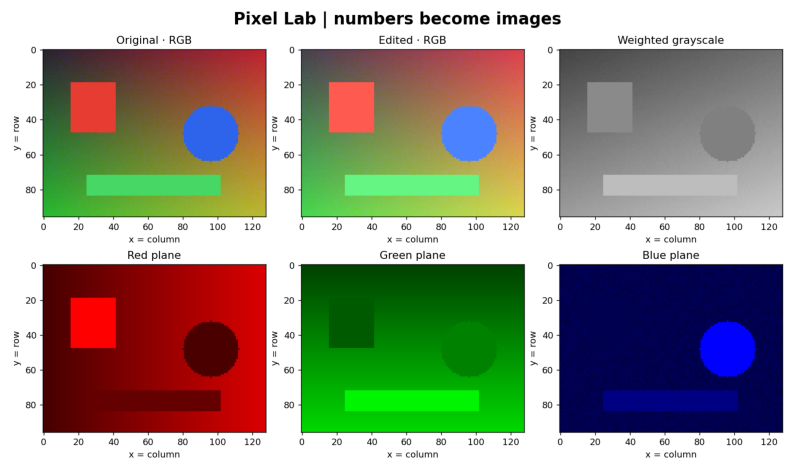

In [8]:
with TemporaryDirectory(prefix="cvzero-report-") as directory:
    report_dir = Path(directory) / "run"
    summary = run_lab(image, report_dir, LabConfig(brightness=30), seed=seed)
    print("Created:", sorted(path.name for path in report_dir.iterdir()))
    print("Edited size:", summary["edited"]["width"], "x", summary["edited"]["height"])
    preview = plt.imread(report_dir / "contact-sheet.png")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(preview)
    ax.set_axis_off()
    plt.show()

## 11. Common Mistakes

- Timing different algorithms and interpreting the result as a library comparison.
- Printing or plotting inside a measured arithmetic loop.
- Including one library's file I/O while excluding it from another.
- Reporting the fastest single sample and hiding variability.
- Describing array storage as peak memory, or pixel equality as ML accuracy.
- Treating arithmetic milliseconds as end-to-end video FPS.

## 12. Exercises

**Easy:** record the mean RGB before and after each offset. Explain why adding 60 does not always increase the mean by exactly 60.

**Medium:** retain the raw timing samples in a JSON report and plot all samples rather than only the median.

**Hard:** investigate sizes at which vectorization helps most. Keep output equality, dtype, warm-up, threads and repetitions controlled, and report a limitation of your protocol.

## 13. Challenge

Build a small benchmark report comparing loop, NumPy and OpenCV on three image sizes. Include raw samples, a correctness check, hardware/package context and a paragraph explaining memory that you did not measure. Choose the visual presentation yourself. No reference solution is supplied.

## 14. Summary

An experiment starts with a precise question and a controlled workload. Correctness comes before speed. Recorded context makes a number interpretable; acknowledging excluded work prevents exaggerated conclusions.

## 15. Next Step

Complete the [Pixel Lab mini project](../mini-project/README.md) and [chapter exercises](../exercises/beginner.md). Then use the checkpoint before [Chapter 02 — Mathematics](../../02-mathematics-for-computer-vision/README.md), the next chapter in the complete course. See [reproducibility guidance](../../docs/reproducibility.md) and [primary references](../../docs/references.md).